  FIXED REGRESSION MODEL BENCHMARKING (ANTI-LOG CRASH)

METRIK EVALUASI      | LINEAR REGRESSION  | RIDGE REGRESSION
MAE                  | 1.2578             | 1.2566         
RMSE                 | 2.2011             | 2.2022         
R-squared (R²)       | 23.85            % | 23.77         %

[PERBANDINGAN BOBOT/KOEFISIEN FITUR (STANDARDIZED)]:
Nama Variabel/Fitur       | Coef Linear     | Coef Ridge     
-------------------------------------------------------------
 ↳ Inflasi_MoM            | 0.9616          | 0.9124         
 ↳ BI_Rate                | 0.4800          | 0.4665         
 ↳ Harga_Minyak_USD       | 0.1663          | 0.1500         
 ↳ IHK                    | 0.3374          | 0.3229         
 ↳ DXY                    | 0.2391          | 0.2027         
-------------------------------------------------------------


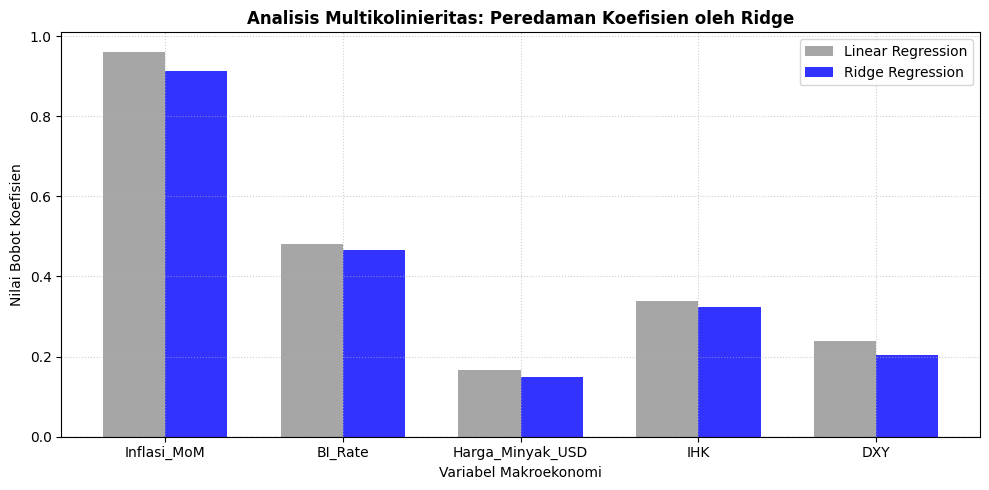

In [6]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split # Tambahan untuk random split
from sklearn.preprocessing import StandardScaler      # Tambahan untuk menyelaraskan skala fitur

print("="*60)
print("  FIXED REGRESSION MODEL BENCHMARKING (ANTI-LOG CRASH)")
print("="*60)

# 1. LOAD DATA
DATA_PATH = "/Users/adrinafirda/ml/Project-Machine-Learning/datasets/processed/clean_inflasi_ts.csv"
df_raw = pd.read_csv(DATA_PATH)

target_col = "Total_Pengeluaran" if "Total_Pengeluaran" in df_raw.columns else df_raw.columns[-1] 
feature_cols = ['Inflasi_MoM', 'BI_Rate', 'Harga_Minyak_USD', 'IHK', 'DXY']
feature_cols = [c for c in feature_cols if c in df_raw.columns]

# Pembersihan data yang kokoh
df_clean = df_raw.dropna(subset=[target_col])
df_clean = df_clean[df_clean[target_col] > 0].reset_index(drop=True)

X_raw = df_clean[feature_cols]
y_raw = df_clean[target_col].values

# 2. STRATEGI PENYELAMATAN: Gunakan Random Train-Test Split (Khusus Kasus Regresi Dampak)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# 3. HANDLING MISSING VALUE
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 4. SCALING FITUR (Penting agar koefisien fitur tidak -0.0000)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test = scaler.transform(X_test_imp)

# 5. TRAINING MODEL
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

model_ridge = Ridge(alpha=10.0) # Naikkan alpha sedikit untuk efek regularisasi yang kelihatan
model_ridge.fit(X_train, y_train)

# 6. EVALUASI METRIK
y_pred_linear = model_linear.predict(X_test)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

y_pred_ridge = model_ridge.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# 7. PRINT HASIL SEHAT WAL AFIAT
print("\n" + "="*55)
print(f"{'METRIK EVALUASI':<20} | {'LINEAR REGRESSION':<18} | {'RIDGE REGRESSION':<15}")
print("="*55)
print(f"{'MAE':<20} | {mae_linear:<18.4f} | {mae_ridge:<15.4f}")
print(f"{'RMSE':<20} | {rmse_linear:<18.4f} | {rmse_ridge:<15.4f}")
print(f"{'R-squared (R²)':<20} | {r2_linear*100:<17.2f}% | {r2_ridge*100:<14.2f}%")
print("="*55)

print("\n[PERBANDINGAN BOBOT/KOEFISIEN FITUR (STANDARDIZED)]:")
print(f"{'Nama Variabel/Fitur':<25} | {'Coef Linear':<15} | {'Coef Ridge':<15}")
print("-" * 61)
for col, coef_l, coef_r in zip(feature_cols, model_linear.coef_, model_ridge.coef_):
    print(f" ↳ {col:<22} | {coef_l:<15.4f} | {coef_r:<15.4f}")
print("-" * 61)

# 8. PLOTTING VISUALISASI PERBANDINGAN KOEFISIEN
x_indices = np.arange(len(feature_cols))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x_indices - width/2, model_linear.coef_, width, label='Linear Regression', color='gray', alpha=0.7)
plt.bar(x_indices + width/2, model_ridge.coef_, width, label='Ridge Regression', color='blue', alpha=0.8)
plt.xlabel('Variabel Makroekonomi')
plt.ylabel('Nilai Bobot Koefisien')
plt.title('Analisis Multikolinieritas: Peredaman Koefisien oleh Ridge', fontsize=12, fontweight='bold')
plt.xticks(x_indices, feature_cols)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()